# Predicting Behavioral Deviation in Smart-Home Sensor Data
### CASAS `ucd002` Testbed — A Trend-Based Approach to Early Behavioral Change Detection

**Research question:** Rather than only detecting unusual days *after* they happen, can trends in
day-to-day behavioral features be used to anticipate deviations from an occupant's own established routine?

**Why this matters:** This kind of pipeline is a building block for applications like aging-in-place
monitoring, where a *gradual drift* in routine (increasing inactivity, disrupted sleep, reduced mobility)
can be an earlier and gentler signal of a health-related change than any single "anomalous" day.

**Dataset:** ~1 year (2025-04-03 to 2026-04-07) of raw sensor events from one occupant's smart home,
18 sensors, 3.70M events, tab-separated `datetime / sensor / message` format.

---
### Notebook structure
1. Raw data loading & quality inspection
2. Preprocessing & occupancy (HOME/AWAY) detection
3. Exploratory data analysis
4. Feature engineering
5. Label generation (no ground truth available)
6. Model training & comparison
7. Feature importance
8. Behavioral trend visualization
9. Discussion: strengths, limitations, future work


## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (12, 5)

import preprocessing, features, labeling, models, evaluate


## 2. Raw data loading & quality inspection

The raw file is tab-separated with format `date time<TAB>sensor<TAB>message<TAB>` (trailing empty field).
Before doing anything else, we look at what's actually in the file — data quality issues found here
directly shape every downstream design decision.

In [2]:
raw = preprocessing.load_raw_events('../data/ucd002.txt')
print(f"{len(raw):,} raw events")
print(f"Date range: {raw['datetime'].min()} to {raw['datetime'].max()}")
print(f"\nSensors ({raw['sensor'].nunique()}):")
print(raw['sensor'].value_counts())


3,703,825 raw events
Date range: 2025-04-03 12:36:20.986892 to 2026-04-07 21:44:06.752292

Sensors (18):
sensor
DiningRoomAArea         815648
KitchenAArea            441481
LivingRoomAArea         404540
KitchenADiningChair     387698
LivingRoomAChair        366685
KitchenASink            286747
BedroomAArea            203235
BedroomABed             170312
HallwayA                169253
BathroomAArea           122575
KitchenAStove            80559
BedroomADoor             79590
BathroomASink            54850
MainEntryway             52927
EntrywayB                29529
BathroomAToilet          23376
KitchenARefrigerator     14781
MainDoor                    39
Name: count, dtype: int64


In [3]:
print("Message types:")
print(raw['message'].value_counts())
print()
print("MainDoor fires only", (raw['sensor']=='MainDoor').sum(),
      "times across the entire year — effectively dead/disconnected for")
print("most of the study period, and uses a different OPEN/CLOSE vocabulary")
print("than every other ON/OFF sensor. We exclude it from the motion/item")
print("feature stream (see preprocessing.split_door_and_motion) and rely on")
print("BedroomADoor for door-usage features instead.")


Message types:


message
OFF      1851976
ON       1851810
OPEN          20
CLOSE         19
Name: count, dtype: int64

MainDoor fires only 39 times across the entire year — effectively dead/disconnected for
most of the study period, and uses a different OPEN/CLOSE vocabulary
than every other ON/OFF sensor. We exclude it from the motion/item
feature stream (see preprocessing.split_door_and_motion) and rely on
BedroomADoor for door-usage features instead.


### Data quality findings

Exploration (see project write-up) surfaced three issues that materially affect the pipeline design:

1. **Two extended zero-activity gaps**: Aug 1–12 (12 days) and Dec 24–Jan 14 (22 days), plus a ragged
   low-activity stretch in mid-October. These are essentially certainly **occupant-absence periods**
   (travel), not sensor failure — the home simply wasn't occupied.
2. **One out-of-order timestamp** (single sensor debounce artifact, negligible).
3. **7 of 3.7M timestamps** are missing the microsecond fraction — handled transparently by
   `pd.to_datetime(..., format='mixed')`.

The absence periods are the important one: if fed into an anomaly/deviation model naively, every
vacation would register as a massive "behavioral anomaly," swamping the much subtler in-home routine
drift this project actually cares about. So we explicitly detect and exclude these as a separate
**occupancy state** before any behavioral modeling — see below.

## 3. Preprocessing & occupancy detection

`preprocessing.label_occupancy` flags a day AWAY if its total event count falls below an empirically
grounded threshold (well below any normally-occupied day's count) **and** it's part of a run of 2+
consecutive such days — the run requirement avoids misclassifying a single low-activity day (e.g. a
day spent resting, which is itself meaningful behavioral signal we don't want to discard) as travel.

In [4]:
events, occupancy = preprocessing.run_preprocessing('../data/ucd002.txt')
print(f"{len(events):,} motion/item/door events after cleaning")
print(f"{occupancy['is_away'].sum()} of {len(occupancy)} calendar days classified AWAY")
print(f"{(~occupancy['is_away']).sum()} HOME days remain for behavioral modeling")


3,703,786 motion/item/door events after cleaning
50 of 370 calendar days classified AWAY
320 HOME days remain for behavioral modeling


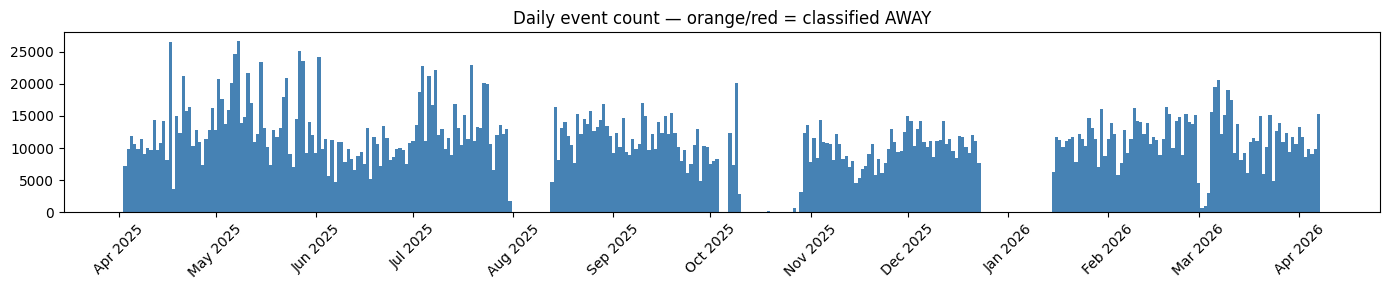

In [5]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(occupancy.index, occupancy['event_count'], width=1,
       color=np.where(occupancy['is_away'], 'salmon', 'steelblue'))
ax.set_title('Daily event count — orange/red = classified AWAY')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/occupancy_timeline.png', dpi=150, bbox_inches='tight')
plt.show()


**Known limitation:** Oct 28 has only 2 events but is *not* flagged AWAY because it's an isolated
day, not part of a 2+ day run. It's almost certainly a travel transition day that our simple rule
can't catch without also risking flagging genuine single low-activity days (e.g. illness) as absences.
This is a deliberate precision/recall tradeoff, not an oversight — noted here for transparency.

## 4. Exploratory data analysis

Sensor category breakdown and daily/hourly activity patterns, restricted to HOME days.

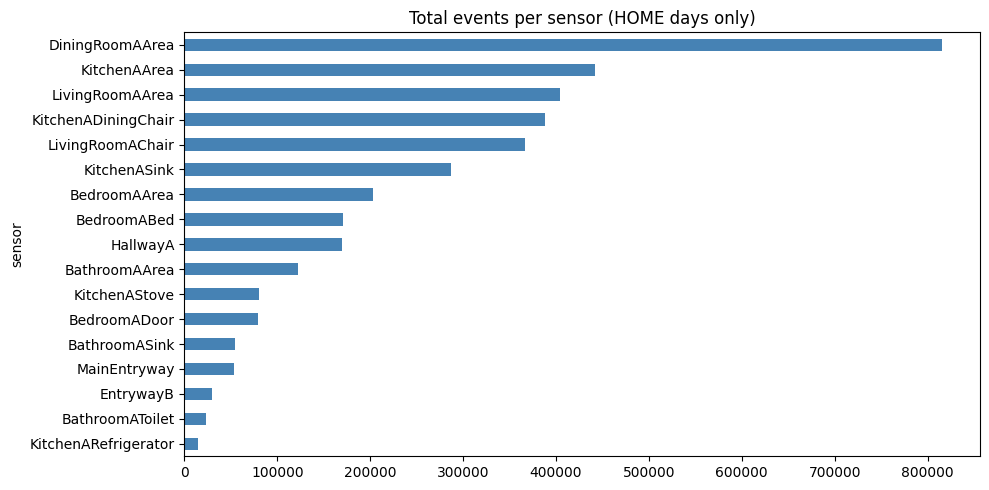

In [6]:
home_events = events[~events['is_away']]
sensor_counts = home_events['sensor'].value_counts()
fig, ax = plt.subplots(figsize=(10,5))
sensor_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Total events per sensor (HOME days only)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/sensor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


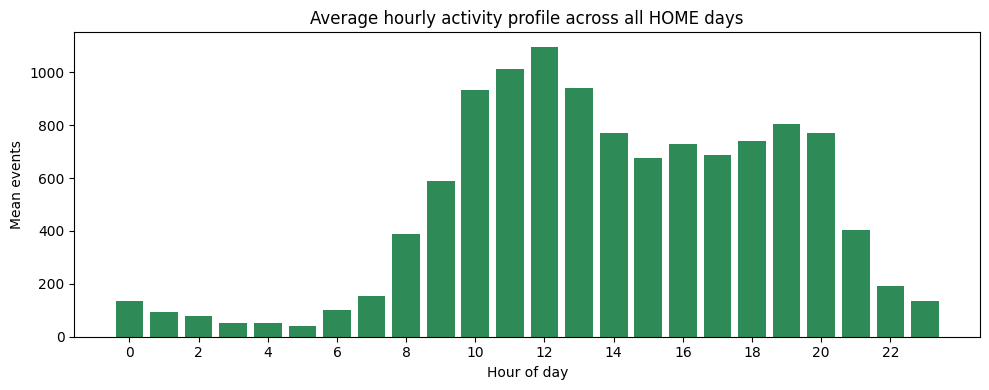

In [7]:
hourly = features.hourly_event_matrix(events)
avg_hourly_profile = hourly.mean(axis=0)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(avg_hourly_profile.index, avg_hourly_profile.values, color='seagreen')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean events')
ax.set_title('Average hourly activity profile across all HOME days')
ax.set_xticks(range(0,24,2))
plt.tight_layout()
plt.savefig('../figures/hourly_profile.png', dpi=150, bbox_inches='tight')
plt.show()


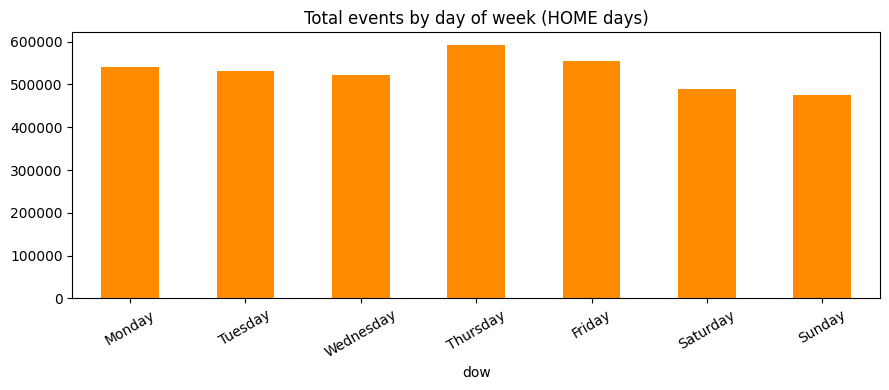

In [8]:
dow_activity = home_events.copy()
dow_activity['dow'] = pd.to_datetime(dow_activity['date']).dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
counts_by_dow = dow_activity.groupby('dow').size().reindex(order)
fig, ax = plt.subplots(figsize=(9,4))
counts_by_dow.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Total events by day of week (HOME days)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../figures/day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Feature engineering

`features.build_feature_matrix` turns the event stream into one row per HOME day covering:
hourly/time-of-day distribution, per-sensor-group activity (motion/item/door), sleep-proxy features,
long daytime inactivity gaps, room transitions, routine-similarity (cosine similarity of today's hourly
shape vs. the person's own recent baseline), calendar features, and rolling 7/14-day mean & std for the
core activity counts.

**Note on scope vs. original feature list:** the originally planned "light usage" feature is **not
measurable** with this sensor set — there are no light sensors in this testbed, only motion (PIR) and
item/contact sensors (see `features.py` docstring for the full taxonomy). Rather than approximate it
with something potentially misleading, it's omitted and documented as a limitation.

In [9]:
feat = features.build_feature_matrix(events)
print(f"Feature matrix: {feat.shape[0]} days x {feat.shape[1]} features")
feat.describe().T[['mean','std','min','50%','max']].round(2)


Feature matrix: 320 days x 45 features


,mean,std,min,50%,max
motion_events,6997.34,2686.16,0.00,6804.50,16059.00
item_events,4328.06,1862.84,2.00,4222.50,11334.00
door_events,248.71,127.38,0.00,228.00,987.00
total_events,11574.11,4427.34,2.00,11315.00,26706.00
unique_sensors_active,15.98,1.41,1.00,16.00,17.00
morning_frac,0.28,0.14,0.00,0.27,0.98
afternoon_frac,0.40,0.17,0.00,0.42,0.84
evening_frac,0.26,0.14,0.00,0.25,1.00
night_frac,0.06,0.07,0.00,0.05,1.00
bed_night_events,165.81,106.49,0.00,151.00,1270.00


## 6. Label generation — no ground truth available

There's no clinician-verified "this was a real behavioral change" label in this dataset, so we
generate one — deliberately using **two independent method families** so we can check whether they
agree (evidence the label reflects a real pattern) rather than trusting a single labeling heuristic
blindly:

1. **Statistical deviation label** (primary): a day is "deviant" if enough individual features fall
   outside the person's own trailing 14-day distribution (|z| >= 2 on 3+ features simultaneously).
2. **Unsupervised anomaly scores** (validation): Isolation Forest & Local Outlier Factor, trained with
   no label at all, purely on the standardized feature matrix.

Agreement between them (Cohen's kappa) is reported below.

In [10]:
labels, agreements = labeling.combine_labels(feat)
print("Label prevalence:")
print(f"  statistical: {labels['label_statistical'].mean():.1%}")
print(f"  isolation forest: {labels['label_isoforest'].mean():.1%}")
print(f"  LOF: {labels['label_lof'].mean():.1%}")
print("\nAgreement with statistical label (Cohen's kappa):")
for k, v in agreements.items():
    print(f"  {k}: {v:.3f}")


Label prevalence:
  statistical: 16.2%
  isolation forest: 10.0%
  LOF: 10.0%

Agreement with statistical label (Cohen's kappa):
  stat_vs_isoforest_kappa: 0.408
  stat_vs_lof_kappa: 0.243


Kappa in the 0.2–0.4 range indicates **fair-to-moderate** agreement — the statistical label
captures a real, structurally-detectable pattern (not pure noise), but the methods aren't redundant
with each other either, which is expected since they're measuring subtly different notions of
"unusual." This agreement analysis is itself a piece of evidence supporting the statistical label as
a reasonable (if imperfect) proxy for supervised training — a genuinely honest research project should
report this rather than assume the label is correct.

## 7. Model training & comparison

**Critical methodological point:** because the research question is framed as *predicting* deviation,
train/test splitting must be **chronological** — training only on the past, testing only on the future.
A random shuffled split would let a model see information from after the day it's predicting, which
isn't prediction at all. `models.chronological_split` and `TimeSeriesSplit` enforce this throughout.

Same-day z-score columns used to construct the label are excluded from the feature set to avoid the
model trivially "predicting" the label by reading back the values that generated it.

In [11]:
X, y = models.prepare_xy(feat, labels)
print(f"X: {X.shape}, positive rate: {y.mean():.1%}")

sup_results, split, scaler = models.run_supervised_comparison(X, y)
X_train, X_test, y_train, y_test = split

print(f"\n{'Model':20s} {'F1':>6s} {'Prec':>6s} {'Recall':>7s} {'ROC-AUC':>8s} {'CV F1':>14s}")
for name, r in sup_results.items():
    h = r['holdout']
    print(f"{name:20s} {h['f1']:6.3f} {h['precision']:6.3f} {h['recall']:7.3f} "
          f"{h.get('roc_auc', float('nan')):8.3f} {r['cv_f1_mean']:6.3f}+/-{r['cv_f1_std']:.3f}")


X: (314, 45), positive rate: 16.2%



Model                    F1   Prec  Recall  ROC-AUC          CV F1
LogisticRegression    0.333  0.375   0.300    0.731  0.352+/-0.147
RandomForest          0.571  1.000   0.400    0.837  0.171+/-0.229
GradientBoosting      0.556  0.625   0.500    0.792  0.296+/-0.114
SVM                   0.667  0.636   0.700    0.879  0.418+/-0.172
XGBoost               0.500  0.667   0.400    0.721  0.412+/-0.095


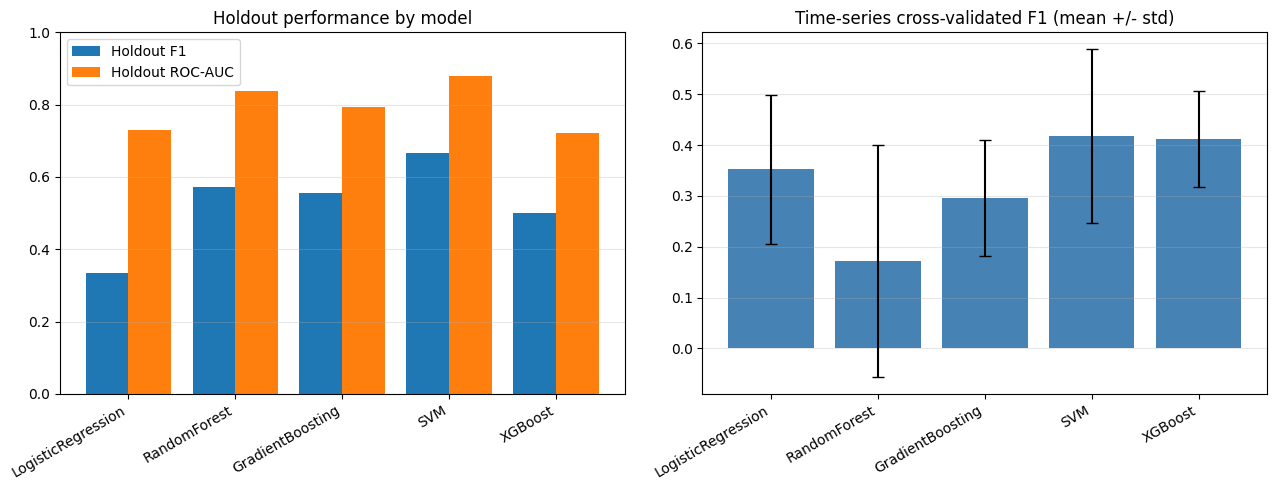

In [12]:
fig = evaluate.plot_model_comparison(sup_results, save_path='../figures/model_comparison.png')
plt.show()


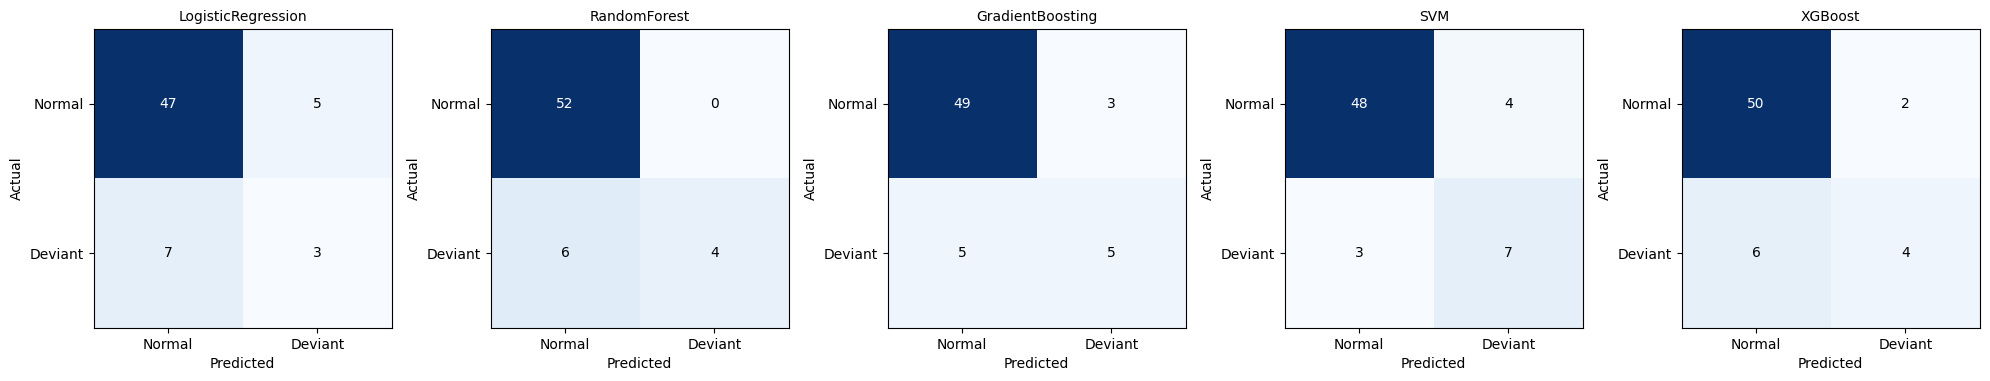

In [13]:
fig = evaluate.plot_confusion_matrices(sup_results, save_path='../figures/confusion_matrices.png')
plt.show()


### Unsupervised comparison (no label used in training)

As a sanity check, we also run the unsupervised anomaly detectors directly and compare their flags to
the statistical label — this tests whether "deviant" days are structurally separable in the raw
feature space at all, independent of any labeling assumption.

In [14]:
unsup_results = models.run_unsupervised_comparison(X, y)
print(f"{'Model':22s} {'F1':>6s} {'Prec':>6s} {'Recall':>7s}")
for name, r in unsup_results.items():
    print(f"{name:22s} {r['f1']:6.3f} {r['precision']:6.3f} {r['recall']:7.3f}")


Model                      F1   Prec  Recall
IsolationForest         0.265  0.344   0.216
OneClassSVM             0.242  0.275   0.216
LocalOutlierFactor      0.241  0.312   0.196


**Interpretation:** Supervised models (trained directly against the statistical label) outperform
the label-blind unsupervised methods on that same label, which is expected — they were given the
target. The unsupervised results are more useful as an independent existence check: they still recover
a meaningful fraction of the same days without ever seeing the label, which supports (but doesn't
prove) that these days are genuinely structurally different, not an artifact of the labeling rule.

With ~314 usable days and a ~16% positive rate (about 50 positive examples), cross-validation
variance is naturally high — a caveat that belongs directly in the report's limitations, not glossed
over.

## 8. Feature importance

Using **permutation importance** rather than each model's built-in importance measure, since
permutation importance is comparable across model families (tree impurity importance and linear
coefficients aren't on the same scale) — important given we explicitly want to compare importance
across several different models, not just describe one.

In [15]:
best_model_name = max(sup_results, key=lambda n: sup_results[n]['holdout']['f1'])
print(f"Best model by holdout F1: {best_model_name}")
best_model = sup_results[best_model_name]['model']

imp = evaluate.get_feature_importance(best_model, X_test, y_test, X.columns)
imp.head(15)


Best model by holdout F1: SVM


,feature,importance_mean,importance_std
34,n_long_inactivity_gaps_roll7_std,0.126865,0.046701
9,bed_night_events,0.113682,0.026320
13,room_transitions,0.103312,0.038025
14,routine_similarity_cos,0.094112,0.027507
15,day_of_week,0.088375,0.033356
0,motion_events,0.087276,0.051317
32,door_events_roll14_std,0.084349,0.062804
3,total_events,0.080262,0.042299
24,motion_events_roll14_std,0.074394,0.045136
1,item_events,0.071299,0.041917


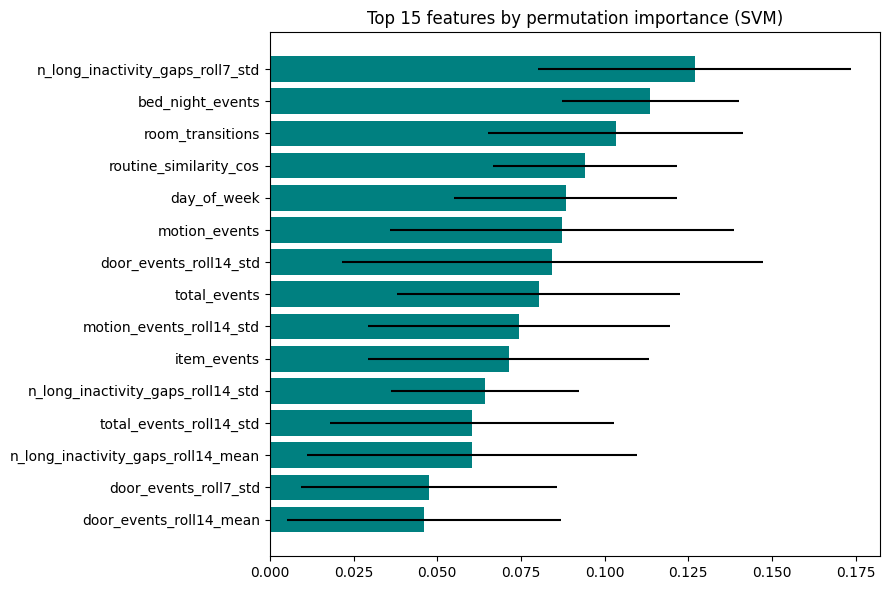

In [16]:
fig, ax = plt.subplots(figsize=(9,6))
top = imp.head(15).iloc[::-1]
ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color='teal')
ax.set_title(f'Top 15 features by permutation importance ({best_model_name})')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Behavioral trend visualization

Long-term view: daily activity with its 14-day rolling mean, flagged deviation days, routine
similarity over time, and long-inactivity-gap trend — the "big picture" view a research demo or
caregiver dashboard would actually show.

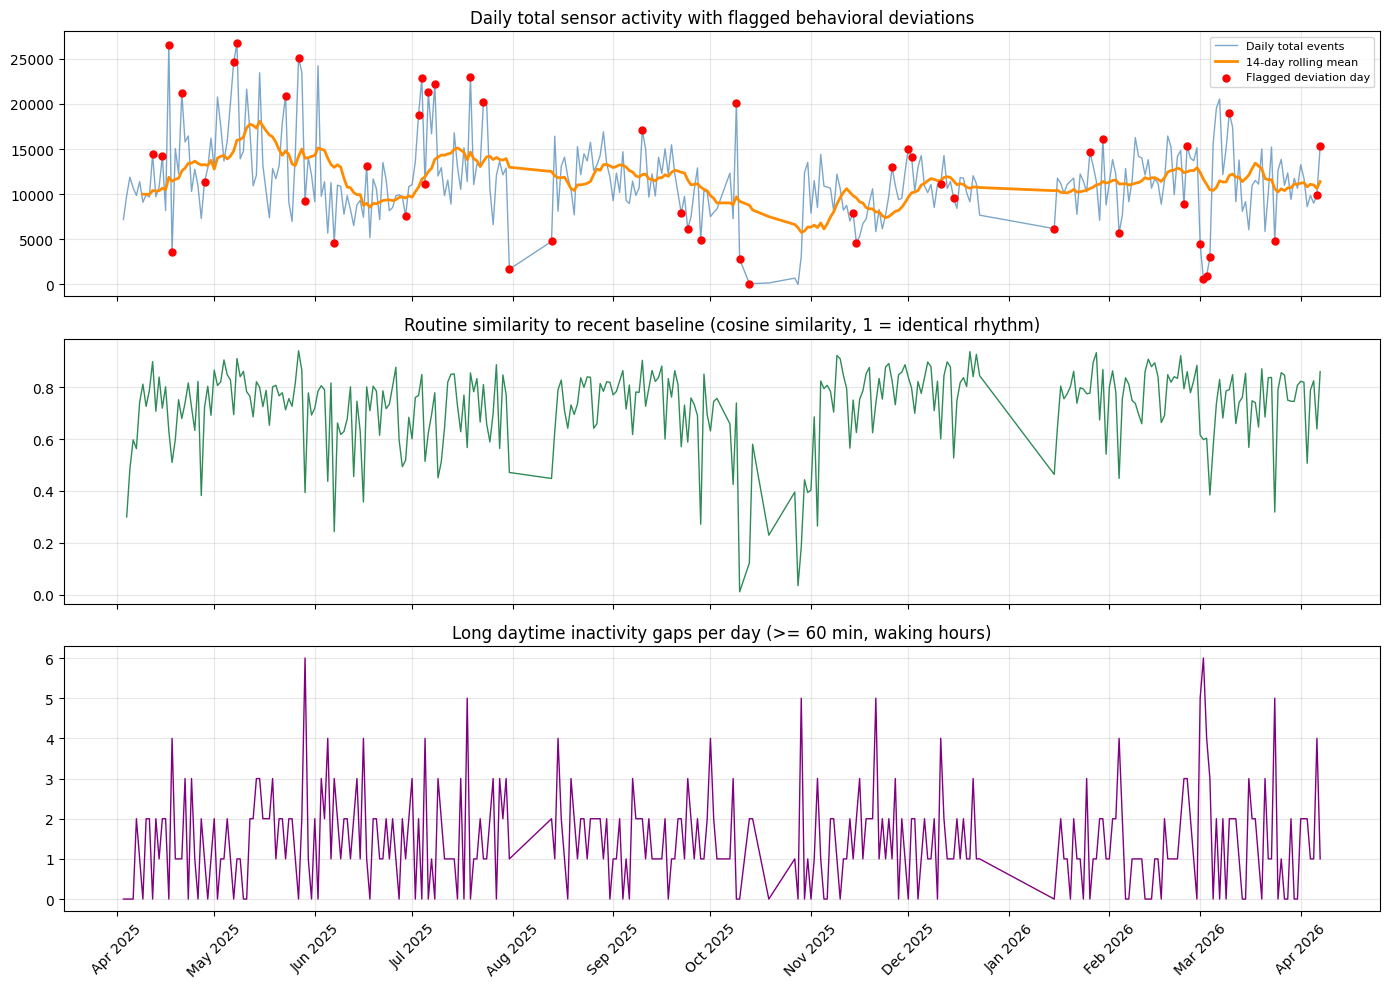

In [17]:
fig = evaluate.plot_behavioral_trends(feat, labels, save_path='../figures/behavioral_trends.png')
plt.show()


## 10. Discussion: strengths, limitations, future work

### Strengths
- Occupancy (HOME/AWAY) detection prevents travel absences from contaminating the "normal routine" baseline
- Labels validated across two independent method families (statistical + unsupervised), with agreement reported rather than assumed
- Chronological train/test splitting throughout — genuinely tests *prediction*, not retrospective classification
- Feature set spans volume, timing, sleep-proxy, mobility, and routine-similarity signals, not just raw counts
- Permutation importance allows fair comparison across very different model types

### Limitations
- **No ground-truth labels exist.** Every reported metric is relative to a self-constructed statistical
  label, not a clinically verified behavioral-change event. Precision/recall/F1 should be read as
  "agreement with our deviation heuristic," not "accuracy at detecting real health changes."
- **Small effective sample size** (~314 usable days, ~50 positive examples) — cross-validation variance
  is high, and any single train/test split's numbers should not be over-interpreted.
- **Single occupant, single home.** No claim of generalization to other households or sensor layouts.
- **No light sensors in this testbed** — the "light usage" feature originally planned isn't measurable
  here.
- **Sleep is inferred, not measured.** BedroomABed and nighttime motion are behavioral proxies, not a
  clinical sleep signal.
- **The Oct 28 edge case** (2 events, not flagged AWAY) illustrates that the occupancy rule, while
  principled, isn't perfect at every boundary.

### Future work
- Longitudinal validation with actual health-outcome data (even self-reported) to check whether
  statistically-flagged deviation days correlate with anything the occupant would independently call
  a "bad day" or health event
- LSTM/GRU sequence models directly on the hourly event matrix (rather than hand-engineered daily
  features) to see whether sequence models find different structure than the feature-engineered
  approach
- Multi-home validation to test whether the same feature set / thresholds generalize
- Formal early-warning framing: instead of same-day classification, explicitly predict deviation
  N days ahead using only features available before that horizon
- Calibrated probability outputs and a proper cost-sensitive threshold, since in a real deployment
  false negatives (missed genuine change) and false positives (alert fatigue) have very different
  costs — currently all models are compared using a threshold-agnostic default cutoff
